# Task 2 -- Restaurant Recommendation System
### Restaurant Intelligence Suite | Cognifyz Technologies ML Internship

## 1. Introduction
This notebook builds a **content-based recommendation engine** that suggests restaurants matching
a user's cuisine, city, budget, price range, and service preferences.

## 2. Business Problem
New or infrequent users have no interaction history for collaborative filtering. A content-based
approach that reasons directly over restaurant attributes works from the very first search,
solving the classic "cold start" problem.

## 3. Objective
Build a `recommend_restaurants()` function returning the top-N restaurants ranked by similarity
to stated user preferences, blended with a quality signal (rating, votes).


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from utils import load_dataset, dataset_summary, set_plot_style, save_fig
from preprocessing import clean_dataset
from feature_engineering import build_feature_set
from recommendation import RestaurantRecommender

set_plot_style()


## 4. Dataset Understanding & 5. Data Cleaning

In [2]:
df_raw = load_dataset('../data/restaurant_dataset.csv')
df = clean_dataset(df_raw)
df = build_feature_set(df)
print(f"Shape ready for recommendation indexing: {df.shape}")
dataset_summary(df)[['dtype','missing_count','unique_values']].head(10)


Shape ready for recommendation indexing: (9551, 32)


,dtype,missing_count,unique_values
Restaurant ID,int64,0,9551
Restaurant Name,str,0,7446
Country Code,int64,0,15
City,str,0,141
Address,str,0,8918
Locality,str,0,1208
Locality Verbose,str,0,1265
Longitude,float64,0,8120
Latitude,float64,0,8677
Cuisines,str,0,1826


## 6. Exploratory Data Analysis -- Recommendation-relevant signals

Figure saved -> ../outputs/figures/task2_top_cuisines.png


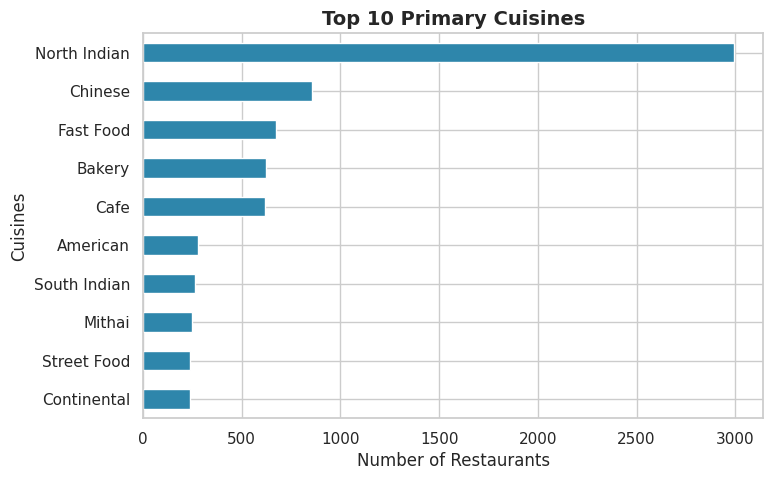

In [3]:
fig, ax = plt.subplots(figsize=(8,5))
df['Cuisines'].str.split(',').str[0].str.strip().value_counts().head(10).sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 10 Primary Cuisines')
ax.set_xlabel('Number of Restaurants')
save_fig(fig, 'task2_top_cuisines')
plt.show()


**Insight:** North Indian, Chinese, and Fast Food dominate cuisine listings, so the content vectorizer must weight rarer cuisines appropriately (TF-IDF handles this automatically by down-weighting very common terms).

Figure saved -> ../outputs/figures/task2_price_range_distribution.png


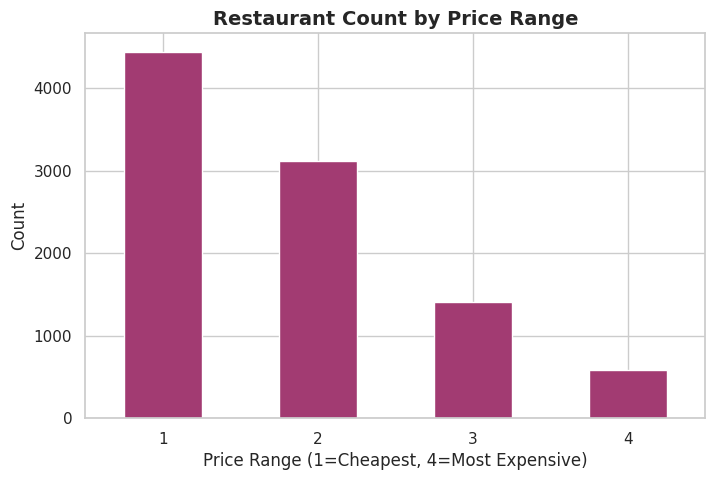

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
df['Price range'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#A23B72')
ax.set_title('Restaurant Count by Price Range')
ax.set_xlabel('Price Range (1=Cheapest, 4=Most Expensive)')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
save_fig(fig, 'task2_price_range_distribution')
plt.show()


**Insight:** Most restaurants sit in price range 1-2 (budget/mid-range), which is why the recommender applies a *hard* budget filter first -- otherwise a similarity-only ranking would still surface expensive places that merely share a cuisine tag.

## 7. Feature Engineering -- Content Profile
The recommender in `src/recommendation.py` builds a per-restaurant **content profile** string
(`Cuisines + City + PriceRange`) and vectorizes it with **TF-IDF**. Cosine similarity between the
user's query vector and every restaurant vector captures categorical fit; this is blended 70/30
with a normalized rating+votes quality score so that among equally relevant matches, the
better-performing restaurant ranks higher.


## 8. Model Development -- Building the Recommender

In [5]:
recommender = RestaurantRecommender(df)
print("TF-IDF vocabulary size:", len(recommender.vectorizer.vocabulary_))
print("Recommender indexed", len(recommender.df), "restaurants.")


TF-IDF vocabulary size: 316
Recommender indexed 9551 restaurants.


## 9. Model Evaluation -- Example Recommendations

In [6]:
# Example 1: Italian food in New Delhi under a budget of 1500
recs1 = recommender.recommend_restaurants(cuisine='Italian', city='New Delhi', budget=1500, top_n=10)
recs1


,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Has Online delivery,Has Table booking,Aggregate rating,Votes,Similarity Score
0,Sinyora's,New Delhi,Italian,500,2,Yes,No,4.0,51,0.7710
1,Pasta Hub,New Delhi,Italian,200,1,No,No,3.0,16,0.7547
2,28 Capri Italy,New Delhi,Italian,1500,3,Yes,Yes,3.9,245,0.7191
3,Food For Thought,New Delhi,"North Indian, Italian",700,2,Yes,No,3.8,55,0.6845
4,Crazy Kitchen Lounge & Terrace,New Delhi,"North Indian, Chinese, Italian",700,2,Yes,No,3.9,176,0.6468
5,The Society Cafe,New Delhi,"Cafe, Italian",800,2,Yes,No,4.1,149,0.6458
6,Da Pizza Farm,New Delhi,Italian,400,1,No,No,0.0,1,0.6443
7,Flaming Chilli Pepper,New Delhi,"Chinese, Italian, North Indian",900,2,Yes,Yes,3.8,286,0.6443
8,Foodies,New Delhi,Italian,300,1,No,No,0.0,0,0.6443
9,Pasta Xpress,New Delhi,"Italian, Fast Food",700,2,Yes,No,3.6,56,0.6354


In [7]:
# Example 2: Chinese food with online delivery, mid price range, anywhere
recs2 = recommender.recommend_restaurants(cuisine='Chinese', price_range=2, online_delivery=True, top_n=10)
recs2


,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Has Online delivery,Has Table booking,Aggregate rating,Votes,Similarity Score
0,Happy Hakka,New Delhi,Chinese,650,2,Yes,No,4.1,173,0.7228
1,Ding Ding,New Delhi,Chinese,600,2,Yes,No,3.9,93,0.7146
2,Casa Asia,New Delhi,Chinese,650,2,Yes,No,3.8,306,0.7132
3,Wok On Wheels,New Delhi,Chinese,550,2,Yes,No,3.8,80,0.7108
4,Chimney Sizzlers,New Delhi,Chinese,800,2,Yes,Yes,3.7,137,0.7077
5,World of Wok,New Delhi,Chinese,500,2,Yes,No,3.6,22,0.7028
6,Hawkers,New Delhi,Chinese,600,2,Yes,No,3.4,398,0.6996
7,Shaolin,New Delhi,Chinese,800,2,Yes,No,3.4,217,0.6976
8,Kitchen & Chicken,New Delhi,Chinese,600,2,Yes,No,3.2,50,0.6884
9,Chinese Hut,New Delhi,Chinese,500,2,Yes,No,3.2,33,0.6882


In [8]:
# Example 3: Table-booking fine dining in the city with the most listings
top_city = df['City'].value_counts().idxmax()
recs3 = recommender.recommend_restaurants(city=top_city, price_range=4, table_booking=True, top_n=10)
print(f"Top city by listing count: {top_city}")
recs3


Top city by listing count: New Delhi


,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Has Online delivery,Has Table booking,Aggregate rating,Votes,Similarity Score
0,Empress of China - Eros Hotel,New Delhi,Chinese,4800,4,No,Yes,4.2,119,0.7783
1,China Kitchen - Hyatt Regency,New Delhi,Chinese,4500,4,No,Yes,4.0,424,0.7743
2,House of Ming - The Taj Mahal Hotel,New Delhi,Chinese,5500,4,No,Yes,4.0,398,0.7740
3,Jade - The Claridges,New Delhi,Chinese,5000,4,No,Yes,3.8,134,0.7637
4,Larry's China - Taj Vivanta,New Delhi,Chinese,3200,4,No,Yes,3.7,147,0.7602
5,Shang Palace - Shangri-La's Eros Hotel,New Delhi,Chinese,5000,4,No,Yes,3.7,65,0.7593
6,Le Belvedere - Le Meridien,New Delhi,Chinese,5000,4,No,Yes,3.5,114,0.7525
7,Dhaba - The Claridges,New Delhi,North Indian,4300,4,No,Yes,3.9,548,0.7509
8,Dilli 32 - The Leela Ambience Convention Hotel,New Delhi,North Indian,3500,4,No,Yes,4.0,184,0.7506
9,Ano Tai - Jaypee Vasant Continental,New Delhi,Chinese,2500,4,No,Yes,3.4,64,0.7483


In [9]:
# Persist example outputs for the report
os.makedirs('../outputs/reports', exist_ok=True)
recs1.to_csv('../outputs/reports/task2_example_recommendations_italian_delhi.csv', index=False)
print("Example recommendations saved.")


Example recommendations saved.


**Recommendation logic explained:**
1. Hard-filter candidates by city, budget ceiling, price range, and Yes/No service preferences --
   these are non-negotiable user constraints, not soft signals.
2. Vectorize the remaining candidates' `Cuisines + City + PriceRange` text with the pre-fit
   TF-IDF model and compute cosine similarity against the user's query text.
3. Blend 70% content similarity with 30% quality score (60% normalized rating + 40% normalized
   votes) into a final `Similarity Score`.
4. Return the top-N restaurants sorted by that blended score.

## 10. Business Insights
- Budget and city are the dominant filters in practice -- most users have a hard price ceiling,
  so applying them *before* ranking (rather than as soft features) avoids frustrating "correct
  cuisine, wrong price" recommendations.
- Blending in a quality signal prevents the system from recommending obscure, low-vote
  restaurants purely because their cuisine tag matches -- a common failure mode of pure
  content-based systems.

## 11. Conclusion
The TF-IDF + cosine-similarity engine, filtered by hard user constraints and re-ranked by a
quality blend, produces relevant, budget-respecting, and well-reviewed recommendations without
requiring any user interaction history.

## 12. Future Improvements
- Add collaborative filtering once user interaction/click data is available, and blend it with
  the content-based score (hybrid recommender).
- Incorporate geo-distance from the user's current location as an additional ranking factor.
- A/B test the 70/30 similarity-quality blend weight against real user engagement.
